<div dir="rtl" align="right">

### سؤال سوم: بررسی اثر داشتن سند تجاری بر قیمت فروش ملک

در سؤال سوم از بخش **آزمون فرض**، از ما خواسته شده است بررسی کنیم که آیا **داشتن سند تجاری بر میانگین قیمت فروش املاک تجاری اثر معناداری دارد یا خیر**.

برای بررسی این موضوع، ابتدا املاک **تجاری** را از داده‌ها انتخاب کردیم و با حذف **قیمت‌های پرت**، داده‌ها را برای انجام آزمون آماری آماده کردیم. سپس املاک تجاری را بر اساس وضعیت سند به دو گروه **دارای سند تجاری** و **فاقد سند تجاری** تقسیم کردیم.

در مرحله بعد، برای هر دو گروه، **میانگین** و **میانه قیمت فروش** را محاسبه کردیم تا تفاوت قیمت بین دو گروه را بررسی کنیم.

سپس برای بررسی معناداری آماری تفاوت بین دو گروه، از دو آزمون آماری استفاده کردیم:

* **Welch's t-test** برای بررسی تفاوت میانگین قیمت فروش دو گروه
* **Mann-Whitney U test** برای بررسی تفاوت توزیع قیمت فروش دو گروه، به‌ویژه در شرایطی که فرض‌های آزمون t مناسب نباشند.

در نهایت، با بررسی نتایج این آزمون‌ها و **مقدار p-value**، مشخص کردیم که آیا تفاوت مشاهده‌شده در قیمت فروش املاک دارای سند تجاری و فاقد سند تجاری از نظر آماری **معنادار** است یا خیر.

</div>


In [5]:
import numpy as np
import pandas as pd
from scipy import stats

#  خواندن داده‌ها
df = pd.read_csv('Divar.csv', low_memory=False)

# انتخاب املاک تجاری
commercial_sales = df[
    (df['cat2_slug'] == 'commercial-sell')
    & df['price_value'].notna()
    & (df['price_value'] > 10000000)
].copy()

#  حذف ۵٪ داده‌های پرت قیمتی از بالا و پایین برای تحلیل دقیق‌تر
q_low = commercial_sales['price_value'].quantile(0.05)
q_high = commercial_sales['price_value'].quantile(0.95)
commercial_clean = commercial_sales[
    (commercial_sales['price_value'] >= q_low)
    & (commercial_sales['price_value'] <= q_high)
].copy()

#  جداسازی دو گروه: دارای سند تجاری و بدون سند تجاری
group_with_deed = commercial_clean[
    commercial_clean['has_business_deed'] == True
]['price_value'].dropna()

group_without_deed = commercial_clean[
    commercial_clean['has_business_deed'] == False
]['price_value'].dropna()

#  میانگین و میانه به میلیارد تومان
mean_with = group_with_deed.mean() / 1e9
median_with = group_with_deed.median() / 1e9

mean_without = group_without_deed.mean() / 1e9
median_without = group_without_deed.median() / 1e9

#  اجرای آزمون‌های آماری
# Welch's t-test
t_stat, p_val_ttest = stats.ttest_ind(
    group_with_deed, group_without_deed, equal_var=False
)

# Mann-Whitney U
u_stat, p_val_mw = stats.mannwhitneyu(
    group_with_deed, group_without_deed, alternative='two-sided'
)

#  خروجی و گزارش نتایج
print('=== آمار توصیفی (بر حسب میلیارد تومان) ===')
print(f'تعداد املاک با سند تجاری: {len(group_with_deed):,}')
print(f'میانگین: {mean_with:.2f}B | میانه: {median_with:.2f}B')
print('-' * 40)
print(f'تعداد املاک بدون سند تجاری: {len(group_without_deed):,}')
print(f'میانگین: {mean_without:.2f}B | میانه: {median_without:.2f}B')

print('\n=== نتایج آزمون‌های فرضیه ===')
print(f'Welch t-test P-value: {p_val_ttest:.4e}')
print(f'Mann-Whitney U P-value: {p_val_mw:.4e}')

alpha = 0.05
if p_val_ttest < alpha or p_val_mw < alpha:
    print(
        '\nنتیجه تحلیل: فرضیه صفر (H0) رد می‌شود.'
    )
    print(
        'داشتن سند تجاری (has_business_deed) ارتباط معناداری از نظر آماری با قیمت فروش ملک دارد.'
    )
else:
    print(
        '\nنتیجه تحلیل: دلیل کافی برای رد فرضیه صفر وجود ندارد (تفاوت قیمت‌ها معنادار نیست).'
    )

=== آمار توصیفی (بر حسب میلیارد تومان) ===
تعداد املاک با سند تجاری: 12,097
میانگین: 7.10B | میانه: 4.00B
----------------------------------------
تعداد املاک بدون سند تجاری: 11,963
میانگین: 6.20B | میانه: 3.30B

=== نتایج آزمون‌های فرضیه ===
Welch t-test P-value: 1.8664e-19
Mann-Whitney U P-value: 1.8946e-33

نتیجه تحلیل: فرضیه صفر (H0) رد می‌شود.
داشتن سند تجاری (has_business_deed) ارتباط معناداری از نظر آماری با قیمت فروش ملک دارد.


با توجه به نتایج به دست آمده هر دو آزمون ارتباط معناداری بین داشتن سند تجاری و قیمت ملک تجاری وجود دارد

در ادامه نمودار جعبه‌ای داده‌های قیمت دو گروه املاک دارای سند تجاری و بدون سند تجاری ترسیم شده‌اند

C:\Users\Data.Norahand\AppData\Local\Temp\ipykernel_18980\1222762469.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


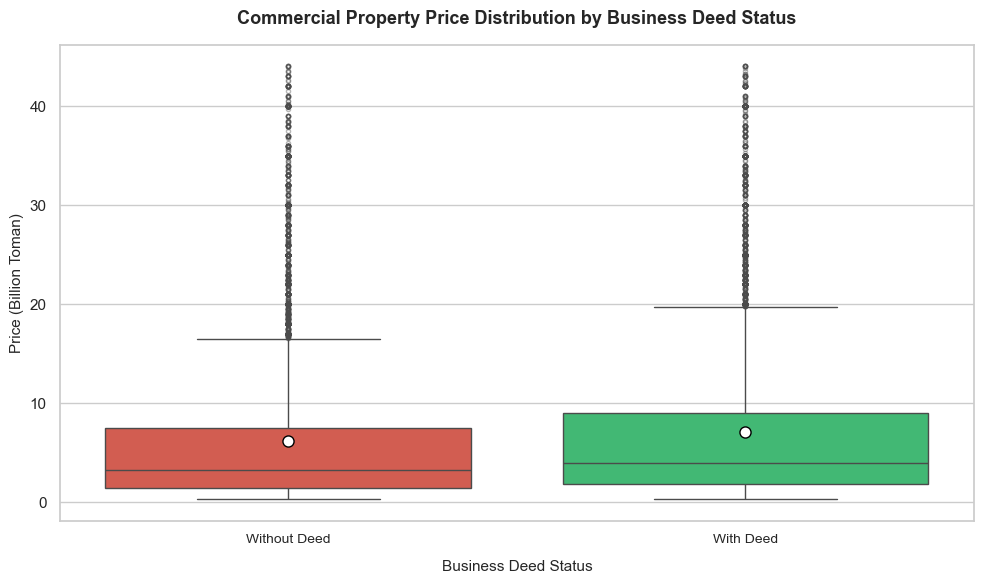

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))


commercial_clean['price_billion'] = commercial_clean['price_value'] / 1e9


ax = sns.boxplot(
    data=commercial_clean,
    x='has_business_deed',
    y='price_billion',
    palette=['#e74c3c', '#2ecc71'],  
    showmeans=True,  
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': 'black',
        'markersize': '8',
    },
    flierprops={
        'marker': 'o',
        'markersize': 3,
        'alpha': 0.4,
    },  
)


plt.title(
    'Commercial Property Price Distribution by Business Deed Status',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Business Deed Status', fontsize=11, labelpad=10)
plt.ylabel('Price (Billion Toman)', fontsize=11)


plt.xticks([0, 1], ['Without Deed', 'With Deed'], fontsize=10)

plt.tight_layout()
plt.show()